# Основы глубинного обучения, майнор ИАД

## Домашнее задание 1: полносвязные сети

**ФИО:**

**Факт о себе:**


## Общая информация

__Дата выдачи:__ 22.09.2025

__Мягкий дедлайн:__ 23:59MSK 12.10.2025

__Жесткий дедлайн:__ 23:59MSK 19.10.2025


## Оценивание и штрафы

Максимально допустимая оценка за работу — 10 баллов. Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).  Если два студента сгенерировали в нейронке одинаковые либо похожие решения, это считается плагиатом и приводит к обнулению обеих работ.

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Итогова оценка считается как

$$
min(part_1, part_2) \cdot 0.6 + max(part_1, part_2) \cdot 0.2 + part_3 \cdot 0.2
$$

где $part_1$, $part_2$ и $part_3$ - оценки за первую, вторую и третью части работы

> Также, за домашнее задание выставляется 0, если не сделано нулевое задание либо нет подробного описания ваших экспериментов в третьей части.

## Оформление

1. Обязательно фиксируйте зерно генератора случайных чисел в экспериментах. При перезапуске кода значения не должны меняться.
2. Вверху файла подпишите фамилию, имя и какой-то занимательный факт о себе.
3. Обратите внимание, что у графиков должны быть подписаны оси, заголовок графика и при необходимости обязательно наличие легенды.

> За отсутствие названий графиков и подписей к осям могут снижаться баллы. Все картинки должны быть самодостаточны и визуально удобны для восприятия, так чтобы не нужно было смотреть ваш код или знать задание, чтобы понять что на них изображено.

Из каждого проведённого эксперимента делайте выводы и фиксируйте их. Эти выводы не должны быть поверхностными и очевидными. Не будьте мудрым королём.

<br>

<center>
<img src="https://raw.githubusercontent.com/hse-ds/iad-deep-learning/refs/heads/master/2025/homeworks/king.png" width="300">
</center>

**Пример плохого вывода:** Синенькая линия идет вверх, а красная вниз. Черненькая идет вниз, а потом вверх.

<br>

<center>
<img src="https://raw.githubusercontent.com/hse-ds/iad-deep-learning/refs/heads/master/2025/homeworks/bad_lines.png" width="600">
</center>

## О задании

Вам предстоит обучить полносвязную нейронную сеть для предсказания года выпуска песни по ее аудио-признакам. Для этого мы будем использовать [Million Songs Dataset](https://samyzaf.com/ML/song_year/song_year.html).

In [1]:
import torch
from torch import nn
import torch.nn.functional as F

import pandas as pd
import numpy as np
import random

from tqdm.notebook import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

Начнем с того, что скачаем и загрузим данные:

In [2]:
!wget -O yearpredictionmsd.zip https://archive.ics.uci.edu/static/public/203/yearpredictionmsd.zip

--2025-10-18 09:03:43--  https://archive.ics.uci.edu/static/public/203/yearpredictionmsd.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘yearpredictionmsd.zip’

yearpredictionmsd.z     [             <=>    ] 201.24M  52.7MB/s    in 4.4s    

2025-10-18 09:03:48 (45.9 MB/s) - ‘yearpredictionmsd.zip’ saved [211011981]



In [3]:
df = pd.read_csv('yearpredictionmsd.zip', header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


Посмотрим на статистики по данным.

In [4]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
count,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,...,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000
mean,1998.397082,43.387126,1.289554,8.658347,1.164124,-6.553601,-9.521975,-2.391089,-1.793236,3.727876,...,15.755406,-73.461500,41.542422,37.934119,0.315751,17.669213,-26.315336,4.458641,20.035136,1.329105
std,10.931046,6.067558,51.580351,35.268585,16.322790,22.860785,12.857751,14.571873,7.963827,10.582861,...,32.099635,175.618889,122.228799,95.050631,16.161764,114.427905,173.977336,13.346557,185.558247,22.088576
min,1922.000000,1.749000,-337.092500,-301.005060,-154.183580,-181.953370,-81.794290,-188.214000,-72.503850,-126.479040,...,-437.722030,-4402.376440,-1810.689190,-3098.350310,-341.789120,-3168.924570,-4319.992320,-236.039260,-7458.378150,-381.424430
25%,1994.000000,39.954690,-26.059520,-11.462710,-8.487500,-20.666450,-18.440990,-10.780600,-6.468420,-2.293660,...,-1.812650,-139.555160,-20.986900,-4.669540,-6.781590,-31.580610,-101.530300,-2.566090,-59.509270,-8.820210
50%,2002.000000,44.258500,8.417850,10.476320,-0.652840,-6.007770,-11.188390,-2.046670,-1.736450,3.822310,...,9.171850,-53.090060,28.791060,33.623630,0.820840,15.598470,-21.204120,3.117640,7.759730,0.053050
75%,2006.000000,47.833890,36.124010,29.764820,8.787540,7.741870,-2.388960,6.508580,2.913450,9.961820,...,26.274480,13.478730,89.661770,77.785800,8.470990,67.794960,52.389330,9.967740,86.351610,9.679520
max,2011.000000,61.970140,384.065730,322.851430,335.771820,262.068870,166.236890,172.402680,126.741270,146.297950,...,840.973380,4469.454870,3210.701700,1734.079690,260.544900,3662.065650,2833.608950,463.419500,7393.398440,677.899630


Целевая переменная, год выпуска песни, записана в первом столбце. Посмотрим на ее распределение.

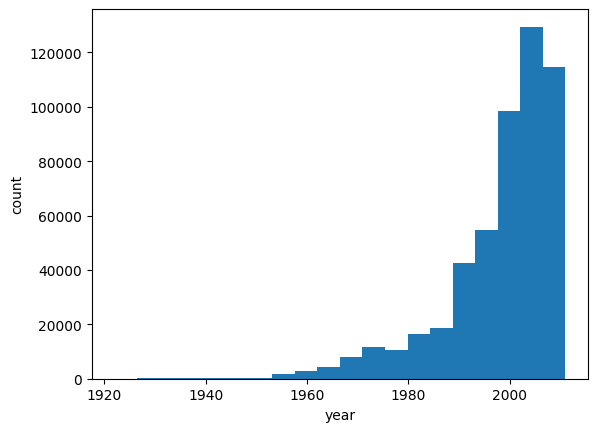

Range: 1922 - 2011
Unique values: 89


In [5]:
plt.hist(df.iloc[:, 0], bins=20)
plt.xlabel('year')
plt.ylabel('count')
plt.show()
print(f'Range: {df.iloc[:, 0].min()} - {df.iloc[:, 0].max()}')
print(f'Unique values: {np.unique(df.iloc[:, 0]).size}')

Разобьем данные на обучение и тест (не меняйте здесь ничего, чтобы сплит был одинаковым у всех).

In [6]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

train_size = int(0.75 * X.shape[0])

X_train = X[:train_size, :]
y_train = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]

X_train.shape, X_test.shape

((386508, 90), (128837, 90))

## Полезные советы:

- Если вы сразу реализуете обучение на GPU, то у вас будет больше времени на эксперименты, так как любые вычисления будут работать быстрее. Google Colab предоставляет несколько GPU-часов (обычно около 8-10) в сутки бесплатно.

- Если вы чего-то не знаете, не стесняйтесь гуглить. В интернете очень много полезной информации, туториалов и советов по глубинному обучению и `pytorch`. Но не забывайте, что за списанный код без ссылки на источник последует наказание.

- Чтобы отладить код, можете обучаться на небольшой части данных или даже на одном батче. Если лосс на обучающей выборке не падает, то что-то точно идет не так.

- Пользуйтесь утилитами, которые вам предоставляет `pytorch` (например, `Dataset` и `Dataloader`). Их специально разработали для упрощения разработки пайплайна обучения.

- Скорее всего, вы захотите отслеживать прогресс обучения. Для создания прогресс-баров есть удобная библиотека `tqdm`.

- Быть может, вы захотите, чтобы графики рисовались прямо во время обучения. Можете воспользоваться функцией [clear_output](http://ipython.org/ipython-doc/dev/api/generated/IPython.display.html#IPython.display.clear_output), чтобы удалять старый график и рисовать новый на его месте.

- При желании вы можете логгировать метрики обучения и свои эксперименты в WandB либо любой другой сервис. Не забудьте приложить к тетрадке ссылку на результаты экспериментов либо скришноты графиков с пояснениями, что проверяющий должен на них увидеть.

- Финальное значение тестовой метрики для удобства проверки выведите в тетрадке.

## Задание 0 (0 баллов, но при невыполнении максимальная оценка за всю работу &mdash; 0 баллов)

Мы будем использовать RMSE как метрику качества. Прежде чем обучать нейронные сети, нам нужно проверить несколько простых бейзлайнов, чтобы было с чем сравнить более сложные алгоритмы. Для этого бучите `Ridge` регрессию из `sklearn`. Кроме того, посчитайте качество при наилучшем константном прогнозе.

Для выполнения данного задания (и всех последующих) предобработайте данные.

1. Зафиксируйте random_seed везде где только возможно. Вам предоставлена функция для этого, однако вы можете дополнить ее своими дополнениями.
2. Обучите `StandertScaler` и предобработайте ваши данные. В следующих заданиях можете использовать другой `scaler` или вообще отказаться от него.


In [7]:
def set_global_seed(seed: int) -> None:
    """Set global seed for reproducibility.
    :param int seed: Seed to be set
    """
    torch.backends.cudnn.deterministic = True
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    # также можно зафиксировать seed для Dataloader
    g = torch.Generator()
    g.manual_seed(seed)
    return g

# Сид для каждого worker в Dataloader
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = set_global_seed(42)

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = Ridge(random_state=42)
model.fit(X_train, y_train)
rmse_for_model = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))
print(rmse_for_model)

# your code here  ⟅⎰᨟﹏᨟⎱⟆

9.47363033268409


Лучшая константа для RMSE это среднее. Используйте среднее, расчитанное на трэйне в качестве прогноза для теста и посчитайте для такой наивной модели RMSE.

In [9]:
 # your code here  ⟅⎛ꌩωꌩ⎞⟆
constant= np.full_like(y_test, fill_value=np.mean(y_train))
best_rmse_metric = np.sqrt(mean_squared_error(y_test, constant))
print(best_rmse_metric )

10.855040840102339


Теперь приступим к экспериментам с нейросетями. Для начала отделим от данных валидацию. Тестовую выборку мы будем использовать только для того, чтобы измерить итоговую метрику качества модели.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0xE2E4)
X_train.shape, X_val.shape

((289881, 90), (96627, 90))

In [11]:
X_train

array([[ 1.14018588,  0.79237009,  0.21243123, ..., -0.164187  ,
         0.82383577, -0.52396833],
       [-0.44866586,  1.02295306, -1.31607127, ...,  1.41033358,
         0.34513051,  1.15136681],
       [ 0.78975149,  0.0595571 , -0.49226919, ...,  0.82395891,
        -0.54954804, -0.34073255],
       ...,
       [-0.19809658, -2.18916706,  1.00462554, ...,  1.9902646 ,
         1.38503168, -1.74601549],
       [-0.59456473,  0.18440031, -0.23553504, ...,  0.36163682,
         0.19926286,  0.39230026],
       [ 0.4993803 ,  0.44946184,  0.92831211, ...,  0.91992497,
        -0.07204652,  0.29579663]])

In [12]:
X_val

array([[ 1.05828421,  0.39642698,  0.38015035, ..., -1.24108618,
        -0.35729907, -0.23779752],
       [ 1.32263234,  0.02485844,  0.410113  , ...,  0.30860959,
         0.11290581, -0.23492462],
       [-1.07484258, -0.92054595, -0.24566046, ..., -1.23050858,
         1.63431675,  0.77439468],
       ...,
       [ 0.97244199,  1.88594332,  1.05641153, ..., -0.30898989,
        -0.29578643,  0.14058705],
       [-1.10227416,  1.29315848, -0.88332322, ..., -0.01946088,
         0.54832839, -0.59511249],
       [-1.89612926, -2.85327179, -0.72603789, ...,  0.02686985,
        -0.8038571 , -0.47320589]])

## Часть I. Обучаем линейную регрессию (максимум 10 баллов)

**Задание 1 (10 баллов):** Обучите в `pytorch` линейную регрессию.

- Создайте модель линейной регрессии, которая будет состоять только из одного `Linear()` слоя.
   
- Напишите цикл обучения вашей линейной регрессии. В нем реализуйте подсчет функции потерь, сделайте шаг градиентного спуска. Запрещено использовать готовые оптимизаторы и loss-функции из библиотеки `pytorch`. Для подсчета градиента воспользуйтесь методом backward.
   
- Запустите обучение на 10 эпохах, после каждой проверяйте значение целевой метрики на тестовой выборке.
   
- Выведите на экран графики метрики и значения функции потерь на тестовой и обучающей выборке.

В данном задании нет цели побить какой-то порог по метрике. Ваша задача &mdash; убедиться в том, что ваш рукописный цикл обучения работает. Для ускорения вычислений и обучения модели можете брать только срез данных, а не весь датасет.

In [13]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

In [14]:
class LinearRegression(nn.Module):
    def __init__(self):
        super(LinearRegression,self).__init__()
        self.linear = nn.Linear(90, 1)

    def forward(self, x):
        return self.linear(x)
model = LinearRegression()

#я так поняла, что нам нельзя пользоваться mse из библиотеки, поэтому напишем ее сами:
def mse(y_pred, y):
    return ((y_pred - y) ** 2).mean()

train_losses, val_losses,val_accuracies = [],[],[]
# я специально поставила очень маленькую learning_rate так как при больших значениях уже на четвертой эпохе ошибка на обеих выборках становилась бесконечостью
learning_rate = 0.0000001
for epoch in range(10):
    model.train()
    y_pred = model(X_train_tensor)
    loss = mse(y_pred, y_train_tensor)
    model.zero_grad()
    loss.backward()
    with torch.no_grad():
        for param in model.parameters():
            param -= learning_rate * param.grad

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_tensor)
        val_loss = mse(val_pred, y_val_tensor)
        a = torch.sum((y_val_tensor - val_pred) ** 2)
        b = torch.sum((y_val_tensor - y_val_tensor.mean()) ** 2)
        r2 = 1 - a/ b
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    val_accuracies.append(r2.item())
    print(f'Epoch: {epoch+1}: train loss: {loss.item():.4f}, val loss: {val_loss.item():.4f}, r2: {r2.item():.4f}')



Epoch: 1: train loss: 3993528.2500, val loss: 3993557.0000, r2: -33048.0625
Epoch: 2: train loss: 3993527.0000, val loss: 3993555.2500, r2: -33048.0469
Epoch: 3: train loss: 3993525.0000, val loss: 3993553.7500, r2: -33048.0352
Epoch: 4: train loss: 3993523.2500, val loss: 3993552.0000, r2: -33048.0195
Epoch: 5: train loss: 3993522.0000, val loss: 3993550.5000, r2: -33048.0078
Epoch: 6: train loss: 3993520.5000, val loss: 3993549.0000, r2: -33047.9961
Epoch: 7: train loss: 3993518.7500, val loss: 3993547.5000, r2: -33047.9844
Epoch: 8: train loss: 3993517.0000, val loss: 3993545.5000, r2: -33047.9648
Epoch: 9: train loss: 3993515.5000, val loss: 3993543.7500, r2: -33047.9531
Epoch: 10: train loss: 3993513.7500, val loss: 3993542.7500, r2: -33047.9453


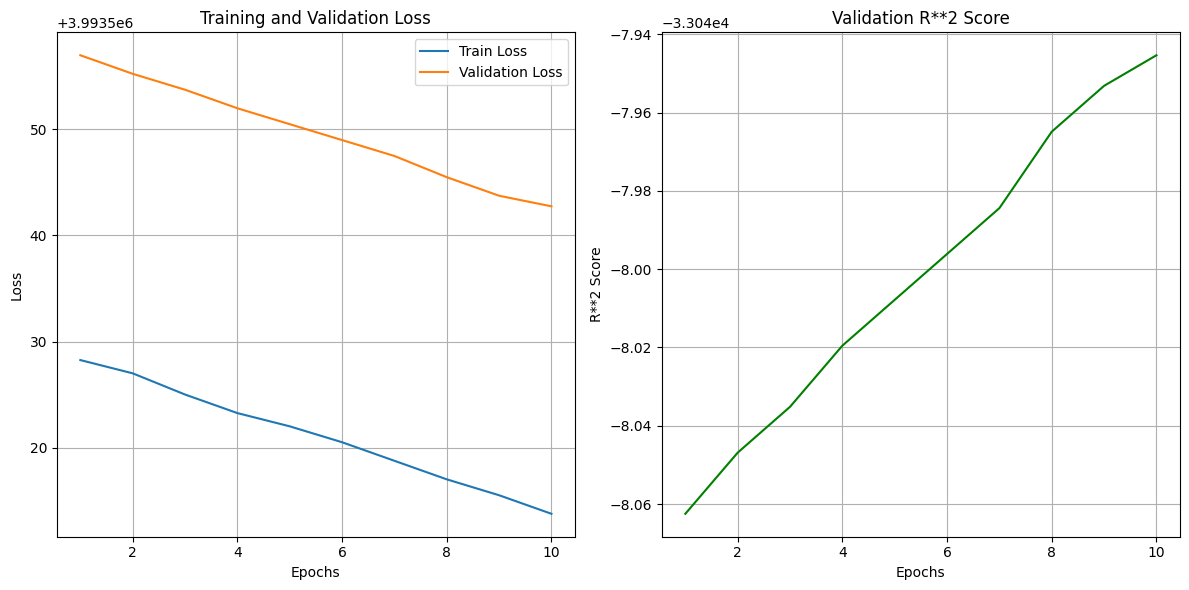


Final weights shape: torch.Size([1, 90])
Final bias shape: torch.Size([1])


In [15]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, 11), train_losses, label='Train Loss')
plt.plot(range(1, 11), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, 11), val_accuracies, label='R**2 Score', color='green')
plt.xlabel('Epochs')
plt.ylabel('R**2 Score')
plt.title('Validation R**2 Score')
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nFinal weights shape:", model.linear.weight.shape)
print("Final bias shape:", model.linear.bias.shape)

## Часть II. Заводим нейронную сеть (максимум 10 баллов)

Ниже нам предстоит реализовать довольно много различных нейросетей и поставить целую серию экспериментов. Чтобы это всё происходило без боли и страданий, нам нужно держать код в удобном виде.

При решении заданий вы можете придерживаться любой адекватной струкуры кода, но мы советуем воспользоваться сигнатурами функций, которые приведены ниже. При необходимости вы можете добавить в них любые нужные вам аргументы и любой нужный функционал. Более того, хорошей практикой является не делать эти функции слишком громоздкими и выносить разные хитрые штуки в отдельные функции.

In [16]:
def training_epoch(model, optimizer, criterion, train_loader):
    """Одна эпоха обучения
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
    """
    model.train()
    c = 0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        c += loss.item()

    average = c / len(train_loader)
    return average
    raise NotImplementedError


@torch.no_grad()

def validation_epoch(model, criterion, val_loader):
    """Одна эпоха валидации модели
    params:
        model - torch.nn.Module to be fitted
        criterion - loss function from torch.nn
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
    """
    model.eval()
    c = 0
    for inputs, targets in val_loader:
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        c += loss.item()

    average = c / len(val_loader)
    return average
    # your code here   ฅ^•ﻌ•^ฅ

    raise NotImplementedError


@torch.no_grad()

def predict(model, data_loader):
    """ Предсказания модели
    params:
        model - torch.nn.Module to be evaluated on test set
        criterion - loss function from torch.nn
        data_loader - torch.utils.data.Dataloader with test set
    ----------
    returns:
        predicts - torch.tensor with shape (len(test_loader.dataset), ),
                   which contains predictions for test objects
    """

    # your code here  =^･ω･^=
    model.eval()
    predicts = []
    y_true=[]

    with torch.no_grad():
        for inputs, labels in data_loader:
            predicts.append(model(inputs).cpu())
            y_true.append(labels.cpu())
    return torch.cat(predicts, dim=0), torch.cat(y_true, dim=0) #torch.sqrt(torch.mean((predicts-y_true)**2)).item()


def train(model, optimizer, criterion, train_loader, val_loader, epochs):
    """ Обучение модели
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
        epochs - number of training epochs
    """

    # your code here  ¯\_(ツ)_/¯
    for epoch in range(epochs):
        train_loss = training_epoch(model, optimizer, criterion, train_loader)
        val_loss = validation_epoch(model, criterion, val_loader)

        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}')



In [17]:
def prepare(X, y):
    unique_years = np.unique(y)
    year_indexes = {year: index for index, year in enumerate(unique_years)}
    y_indexes = np.array([year_indexes[year] for year in y])

    return X, y_indexes, year_indexes,y

In [18]:
def rmse(predictions, targets):
    return np.sqrt(np.mean((predictions - targets) ** 2))

**Задание 2 (2 балла)**

Попробуем обучить нашу первую нейронную сеть. Здесь целевая переменная дискретная &mdash; это год выпуска песни. Поэтому будем учить сеть на классификацию.

- В качестве архитектуры сети возьмите два линейных слоя с активацией ReLU между ними c числом скрытых нейронов, равным 128.
- Используйте SGD с `lr=1e-3`.
- Возьмите размер мини-батча около 32-64, примерно 3-4 эпох обучения должно быть достаточно.
- Также преобразуйте целевую переменную так, чтобы ее значения принимали значения от $0$ до $C-1$, где $C$ &mdash; число классов (лучше передайте преобразованное значение в DataLoader, исходное нам еще пригодится)
- В качестве метрики качества мы используем RMSE. При его подсчёте вам нужно заменить предсказанный нейросеткой класс на конкретный год выпуска песни и использовать его как прогноз.

In [19]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
class ClassificationNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(ClassificationNN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes))

    def forward(self, x):
        return self.model(x)

X_train, indexed_targets_train, year_to_index_train,_ = prepare(X_train, y_train)
X_val, indexed_targets_val, _, y_val = prepare(X_val, y_val)

train_dataset = TensorDataset(torch.tensor(X_train,dtype=torch.float32), torch.tensor(indexed_targets_train).long())
val_dataset = TensorDataset(torch.tensor(X_val,dtype=torch.float32), torch.tensor(indexed_targets_val).long())
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32)

model = ClassificationNN(X_train.shape[1], len(np.unique(indexed_targets_train)))
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-3)

train(model, optimizer, criterion, train_loader, val_loader, epochs=4)
predictions, y_true = predict(model, val_loader)
predicted_classes = torch.argmax(predictions, dim=1)
index_to_year_train = {y: x for x, y in year_to_index_train.items()}
predicted_years = [index_to_year_train[i] for i in predicted_classes.cpu().numpy() if i in index_to_year_train]
true_years=[index_to_year_train[i.item()] for i in y_true]
rmse_classification= rmse(np.array(predicted_years), np.array(true_years))
print(f'Validation RMSE: {rmse_classification:.4f}')



Epoch [1/4], Train Loss: 3.8702, Validation Loss: 3.6164
Epoch [2/4], Train Loss: 3.4910, Validation Loss: 3.4892
Epoch [3/4], Train Loss: 3.4080, Validation Loss: 3.4355
Epoch [4/4], Train Loss: 3.3627, Validation Loss: 3.4015
Validation RMSE: 13.4270


**Задание 3 (1 балл).** Прокомментируйте ваши наблюдения. Удалось ли побить бейзлайн? Как вы думаете, хорошая ли идея учить классификатор для этой задачи? Почему?

**Ответ:** ...


In [20]:
X_train

array([[ 1.14018588,  0.79237009,  0.21243123, ..., -0.164187  ,
         0.82383577, -0.52396833],
       [-0.44866586,  1.02295306, -1.31607127, ...,  1.41033358,
         0.34513051,  1.15136681],
       [ 0.78975149,  0.0595571 , -0.49226919, ...,  0.82395891,
        -0.54954804, -0.34073255],
       ...,
       [-0.19809658, -2.18916706,  1.00462554, ...,  1.9902646 ,
         1.38503168, -1.74601549],
       [-0.59456473,  0.18440031, -0.23553504, ...,  0.36163682,
         0.19926286,  0.39230026],
       [ 0.4993803 ,  0.44946184,  0.92831211, ...,  0.91992497,
        -0.07204652,  0.29579663]])

In [21]:
y_train

array([2001, 1996, 2009, ..., 2003, 1977, 1999])

In [22]:
X_val

array([[ 1.05828421,  0.39642698,  0.38015035, ..., -1.24108618,
        -0.35729907, -0.23779752],
       [ 1.32263234,  0.02485844,  0.410113  , ...,  0.30860959,
         0.11290581, -0.23492462],
       [-1.07484258, -0.92054595, -0.24566046, ..., -1.23050858,
         1.63431675,  0.77439468],
       ...,
       [ 0.97244199,  1.88594332,  1.05641153, ..., -0.30898989,
        -0.29578643,  0.14058705],
       [-1.10227416,  1.29315848, -0.88332322, ..., -0.01946088,
         0.54832839, -0.59511249],
       [-1.89612926, -2.85327179, -0.72603789, ...,  0.02686985,
        -0.8038571 , -0.47320589]])

In [23]:
y_val

array([2006, 2003, 2003, ..., 1990, 1987, 2003])

**Задание 4 (2 балла).** Теперь попробуем решать задачу как регрессию. Обучите нейронную сеть на MSE.

- Используйте такие же гиперпараметры обучения.
- Когда передаете целевую переменную в DataLoader, сделайте reshape в (-1, 1).
- Если что-то пойдет не так, можете попробовать меньшие значения `lr`.

In [24]:
y_train = y_train.reshape(-1, 1)
y_val = y_val.reshape(-1, 1)

train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

class RegressionNN(nn.Module):
    def __init__(self, input_size):
        super(RegressionNN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.model(x)
model = RegressionNN(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=1e-5)
train(model, optimizer, criterion, train_loader, val_loader, epochs=3)
predictions,y_true = predict(model, val_loader)
predicted_years = predictions.numpy().flatten()
rmse_regression = rmse(predicted_years,y_true.numpy().flatten())
print(f'Validation RMSE: {rmse_regression:.4f}')

Epoch [1/3], Train Loss: 40251.4796, Validation Loss: 175.0040
Epoch [2/3], Train Loss: 233.6269, Validation Loss: 124.0532
Epoch [3/3], Train Loss: 173.2185, Validation Loss: 120.7631
Validation RMSE: 10.9897


In [25]:
predicted_years

array([2006.9529, 2000.6189, 1999.662 , ..., 1995.8741, 1988.0261,
       1996.5322], dtype=float32)

In [26]:
y_true

tensor([[2006.],
        [2003.],
        [2003.],
        ...,
        [1990.],
        [1987.],
        [2003.]])

**Задание 5 (1 балл).** Получилось ли у вас стабилизировать обучение? Помогли ли меньшие значения `lr`? Стало ли лучше от замены классификации на регрессию? Как вы думаете, почему так происходит? В качестве подсказки можете посмотреть на распределение целевой переменной и магнитуду значений признаков.

**Ответ:** ...

**Задание 6 (1 балл).** Начнем с того, что попробуем отнормировать целевую переменную. Для этого воспользуемся min-max нормализацией, чтобы целевая переменная принимала значения от 0 до 1. Реализуйте функции `normalize` и `denormalize`, которые, соответственно, нормируют целевую переменную и применяют обратное преобразование. Минимум и максимум оцените по обучающей выборке (то есть эти константы должны быть фиксированными и не зависеть от передаваемой выборки).

In [27]:
min_value = np.min(y_train)
max_value = np.max(y_train)
def normalize(sample):
    """
    Min-max normalization to convert sample to [0, 1] range
    """
    if min_value!=max_value:
      return (sample - min_value) / (max_value - min_value)
    else:
      return np.zeros_like(sample)

def denormalize(sample):
    """
    Denormalize sample from [0, 1] to initial range
    """
    return sample * (max_value - min_value) + min_value
    # your code here ( ⚆ ω ⚆)

**Задание 7 (1 балл)** Теперь повторите эксперимент из **задания 4**, обучаясь на нормированной целевой переменной. Сделаем также еще одно изменение: добавим сигмоидную активацию после последнего линейного слоя сети. Таким образом мы гарантируем, что нейронная сеть предсказывает числа из промежутка $[0, 1]$. Использование активации - довольно распространенный прием, когда мы хотим получить числа из определенного диапазона значений.

In [28]:
y_train_normalized = normalize(y_train).reshape(-1, 1)
y_val_normalized = normalize(y_val).reshape(-1, 1)

train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train_normalized, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val_normalized, dtype=torch.float32))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

class RegressionSigmoidNN(nn.Module):
    def __init__(self, input_size):
        super(RegressionSigmoidNN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)
model = RegressionSigmoidNN(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=1e-3)
train(model, optimizer, criterion, train_loader, val_loader, epochs=3)
predictions,y_true= predict(model, val_loader)
predictions=denormalize(predictions).numpy().flatten()
y_true=denormalize(y_true).numpy().flatten()
rmse_sigmoid = rmse(predictions, y_true)
print(f'Validation RMSE: {rmse_sigmoid:.2f}')
# your code here  ლ(ಠ益ಠლ)

Epoch [1/3], Train Loss: 0.0288, Validation Loss: 0.0167
Epoch [2/3], Train Loss: 0.0159, Validation Loss: 0.0156
Epoch [3/3], Train Loss: 0.0151, Validation Loss: 0.0150
Validation RMSE: 10.91


**Задание 8 (2 балла).** На этот раз попробуем отнормировать не только целевую переменную, но и сами данные, которые подаются сети на вход. Для них будем использовать нормализацию через среднее и стандартное отклонение. Преобразуйте данные и повторите прошлый эксперимент. Скорее всего, имеет смысл увеличить число эпох обучения.

In [29]:
X_train_normalized = scaler.fit_transform(X_train)
X_val_normalized = scaler.transform(X_val)
train_dataset = TensorDataset(torch.tensor(X_train_normalized, dtype=torch.float32), torch.tensor(y_train_normalized, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val_normalized, dtype=torch.float32), torch.tensor(y_val_normalized, dtype=torch.float32))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

model = RegressionSigmoidNN(X_train_normalized.shape[1])
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=1e-3)
train(model, optimizer, criterion, train_loader, val_loader, epochs=9)
predictions,y_true= predict(model, val_loader)
predictions=denormalize(predictions).numpy().flatten()
y_true=denormalize(y_true).numpy().flatten()
rmse_sigmoid_normalized = rmse(predictions, y_true)
print(f'Validation RMSE: {rmse_sigmoid_normalized:.2f}')
 # your code here  ( ͡° ͜ʖ ͡°)

Epoch [1/9], Train Loss: 0.0284, Validation Loss: 0.0162
Epoch [2/9], Train Loss: 0.0154, Validation Loss: 0.0151
Epoch [3/9], Train Loss: 0.0146, Validation Loss: 0.0145
Epoch [4/9], Train Loss: 0.0141, Validation Loss: 0.0141
Epoch [5/9], Train Loss: 0.0138, Validation Loss: 0.0138
Epoch [6/9], Train Loss: 0.0135, Validation Loss: 0.0135
Epoch [7/9], Train Loss: 0.0133, Validation Loss: 0.0133
Epoch [8/9], Train Loss: 0.0131, Validation Loss: 0.0131
Epoch [9/9], Train Loss: 0.0130, Validation Loss: 0.0130
Validation RMSE: 10.14


Если вы все сделали правильно, то у вас должно было получиться качество, сравнимое с `Ridge` регрессией.

**Мораль:** как видите, нам пришлось сделать очень много хитрых телодвижений, чтобы нейронная сеть работала хотя бы так же, как и простая линейная модель. Здесь, конечно, показан совсем экстремальный случай, когда без нормализации данных нейронная сеть просто не учится. Как правило, в реальности завести нейронную сеть из коробки не очень сложно, но вот заставить ее работать на полную &mdash; куда более трудоемкая задача. Написание пайплайнов обучения нейросетевых моделей требует большой аккуратности, а дебаг часто превращается в угадайку. К счастью, очень часто на помощь приходит интуиция, и мы надеемся, что вы сможете выработать ее в течение нашего курса. Начнем с двух советов, которые стоит принять на вооружение:

- Обязательно начинаем любые эксперименты с бейзлайнов: без них мы бы не поняли, что нейронная сеть не учится в принципе.
- При постановке эксперментов старайтесь делать минимальное количество изменений за раз (в идеале одно!): только так можно понять, какие конкретно изменения влияют на результат.

## Часть III. Улучшаем нейронную сеть (максимум 10 баллов)

Продолжим экспериментировать с нейронной сетью, чтобы добиться еще лучшего качества.

**Задание 9 (1 балл).** Давайте попробуем другие оптимизаторы. Обучите нейросеть с помощью SGD+momentum и Adam. Опишите свои наблюдения и в дальнейших запусках используйте лучший оптимизатор. Для Adam обычно берут learning rate поменьше, в районе $10^{-3}$.

In [30]:
model= RegressionSigmoidNN(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
train(model, optimizer, criterion, train_loader, val_loader, epochs=7)
predictions,y_true= predict(model, val_loader)
predictions=denormalize(predictions).numpy().flatten()
y_true=denormalize(y_true).numpy().flatten()
rmse_sigmoid_normalized = rmse(predictions, y_true)
print(f'Validation RMSE: {rmse_sigmoid_normalized:.2f}')

Epoch [1/7], Train Loss: 0.0119, Validation Loss: 0.0109
Epoch [2/7], Train Loss: 0.0105, Validation Loss: 0.0105
Epoch [3/7], Train Loss: 0.0102, Validation Loss: 0.0103
Epoch [4/7], Train Loss: 0.0101, Validation Loss: 0.0103
Epoch [5/7], Train Loss: 0.0100, Validation Loss: 0.0102
Epoch [6/7], Train Loss: 0.0099, Validation Loss: 0.0101
Epoch [7/7], Train Loss: 0.0099, Validation Loss: 0.0101
Validation RMSE: 8.95


In [31]:
model= RegressionSigmoidNN(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
train(model, optimizer, criterion, train_loader, val_loader, epochs=7)
predictions,y_true= predict(model, val_loader)
predictions=denormalize(predictions).numpy().flatten()
y_true=denormalize(y_true).numpy().flatten()
rmse_sigmoid_normalized = rmse(predictions, y_true)
print(f'Validation RMSE: {rmse_sigmoid_normalized:.2f}')

Epoch [1/7], Train Loss: 0.0109, Validation Loss: 0.0102
Epoch [2/7], Train Loss: 0.0100, Validation Loss: 0.0100
Epoch [3/7], Train Loss: 0.0098, Validation Loss: 0.0100
Epoch [4/7], Train Loss: 0.0097, Validation Loss: 0.0100
Epoch [5/7], Train Loss: 0.0096, Validation Loss: 0.0100
Epoch [6/7], Train Loss: 0.0095, Validation Loss: 0.0099
Epoch [7/7], Train Loss: 0.0095, Validation Loss: 0.0099
Validation RMSE: 8.84


**Задание 10 (1 балл).** Теперь сделаем нашу нейронную сеть более сложной. Попробуйте сделать сеть:

- более широкой (то есть увеличить размерность скрытого слоя, например, вдвое)
- более глубокой (то есть добавить еще один скрытый слой)

In [32]:
class RegressionSigmoidNN(nn.Module):
    def __init__(self, input_size):
        super(RegressionSigmoidNN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)
model= RegressionSigmoidNN(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
train(model, optimizer, criterion, train_loader, val_loader, epochs=7)
predictions,y_true= predict(model, val_loader)
predictions=denormalize(predictions).numpy().flatten()
y_true=denormalize(y_true).numpy().flatten()
rmse_sigmoid_normalized = rmse(predictions, y_true)
print(f'Validation RMSE: {rmse_sigmoid_normalized:.2f}')

Epoch [1/7], Train Loss: 0.0105, Validation Loss: 0.0100
Epoch [2/7], Train Loss: 0.0098, Validation Loss: 0.0098
Epoch [3/7], Train Loss: 0.0095, Validation Loss: 0.0098
Epoch [4/7], Train Loss: 0.0093, Validation Loss: 0.0097
Epoch [5/7], Train Loss: 0.0092, Validation Loss: 0.0102
Epoch [6/7], Train Loss: 0.0090, Validation Loss: 0.0097
Epoch [7/7], Train Loss: 0.0088, Validation Loss: 0.0096
Validation RMSE: 8.73


Опишите, как увеличение числа параметров модели влияет на качество на обучающей и валидационной выборках (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__

**Задание 11 (1 балл).** Как вы должны были заметить, более сложная модель стала сильнее переобучаться. Попробуем разные методы регуляризации, чтобы бороться с переобучением. Проведите два эксперимента:

- Добавьте слой дропаута с параметром $p=0.2$ после каждого линейного слоя, кроме последнего.
- Попробуйте batch-нормализацию вместо дропаута. Строго говоря, batch-нормализация не является методом регуляризации, но никто не запрещает нам экспериментировать с ней.

In [33]:
class RegressionSigmoidNN(nn.Module):
    def __init__(self, input_size, dropout_rate=0.2):
        super(RegressionSigmoidNN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)
model= RegressionSigmoidNN(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
train(model, optimizer, criterion, train_loader, val_loader, epochs=7)
predictions,y_true= predict(model, val_loader)
predictions=denormalize(predictions).numpy().flatten()
y_true=denormalize(y_true).numpy().flatten()
rmse_sigmoid_normalized = rmse(predictions, y_true)
print(f'Validation RMSE: {rmse_sigmoid_normalized:.2f}')

Epoch [1/7], Train Loss: 0.0108, Validation Loss: 0.0104
Epoch [2/7], Train Loss: 0.0101, Validation Loss: 0.0100
Epoch [3/7], Train Loss: 0.0099, Validation Loss: 0.0098
Epoch [4/7], Train Loss: 0.0098, Validation Loss: 0.0098
Epoch [5/7], Train Loss: 0.0097, Validation Loss: 0.0098
Epoch [6/7], Train Loss: 0.0096, Validation Loss: 0.0097
Epoch [7/7], Train Loss: 0.0096, Validation Loss: 0.0097
Validation RMSE: 8.76


In [34]:
class RegressionSigmoidNN(nn.Module):
    def __init__(self, input_size):
        super(RegressionSigmoidNN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)
model= RegressionSigmoidNN(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
train(model, optimizer, criterion, train_loader, val_loader, epochs=7)
predictions,y_true= predict(model, val_loader)
predictions=denormalize(predictions).numpy().flatten()
y_true=denormalize(y_true).numpy().flatten()
rmse_sigmoid_normalized = rmse(predictions, y_true)
print(f'Validation RMSE: {rmse_sigmoid_normalized:.2f}')

Epoch [1/7], Train Loss: 0.0107, Validation Loss: 0.0100
Epoch [2/7], Train Loss: 0.0100, Validation Loss: 0.0099
Epoch [3/7], Train Loss: 0.0097, Validation Loss: 0.0098
Epoch [4/7], Train Loss: 0.0096, Validation Loss: 0.0096
Epoch [5/7], Train Loss: 0.0094, Validation Loss: 0.0095
Epoch [6/7], Train Loss: 0.0093, Validation Loss: 0.0095
Epoch [7/7], Train Loss: 0.0092, Validation Loss: 0.0096
Validation RMSE: 8.71


Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__

**Задание 12 (1 балл).** Теперь, когда мы определились с выбором архитектуры нейронной сети, пора заняться рутиной DL-инженера &mdash; перебором гиперпараметров. Подберите оптимальное значение lr по значению RMSE на валидации (по логарифмической сетке, достаточно посмотреть 3-4 значения). Затем подберите оптимальное значение weight decay для данного lr (тоже по логарифмической сетке, типичные значения этого параметра лежат в диапазоне $[10^{-6}, 10^{-3}]$, но не забудьте включить нулевое значение в сетку). Постройте графики зависимости RMSE на трейне и на валидации от значений параметров. Прокомментируйте получившиеся зависимости.

Epoch [1/4], Train Loss: 0.0325, Validation Loss: 0.0115
Epoch [2/4], Train Loss: 0.0112, Validation Loss: 0.0109
Epoch [3/4], Train Loss: 0.0108, Validation Loss: 0.0106
Epoch [4/4], Train Loss: 0.0106, Validation Loss: 0.0105
Epoch [1/4], Train Loss: 0.0121, Validation Loss: 0.0103
Epoch [2/4], Train Loss: 0.0101, Validation Loss: 0.0099
Epoch [3/4], Train Loss: 0.0098, Validation Loss: 0.0100
Epoch [4/4], Train Loss: 0.0096, Validation Loss: 0.0099
Epoch [1/4], Train Loss: 0.0108, Validation Loss: 0.0101
Epoch [2/4], Train Loss: 0.0100, Validation Loss: 0.0099
Epoch [3/4], Train Loss: 0.0097, Validation Loss: 0.0097
Epoch [4/4], Train Loss: 0.0096, Validation Loss: 0.0098

Оптимальный learning rate: 0.001 (Val RMSE: 8.793357)


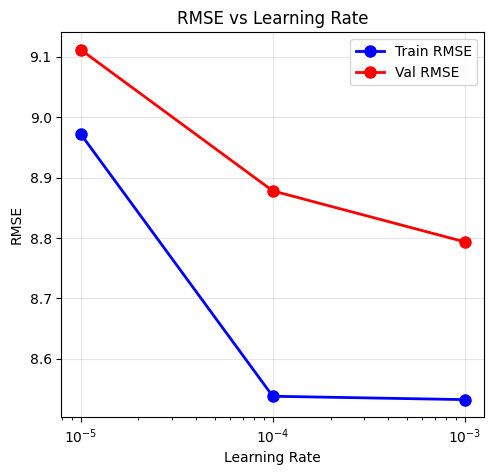

In [38]:
rates = [1e-5, 1e-4, 1e-3]
lr_results = []

for lr in rates:
    model = RegressionSigmoidNN(X_train_normalized.shape[1])
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train(model, optimizer, criterion, train_loader, val_loader, epochs=4)

    predictions,y_true= predict(model, train_loader)
    predictions=denormalize(predictions).numpy().flatten()
    y_true=denormalize(y_true).numpy().flatten()
    rmse_train = rmse(predictions, y_true)

    predictions,y_true= predict(model, val_loader)
    predictions=denormalize(predictions).numpy().flatten()
    y_true=denormalize(y_true).numpy().flatten()
    rmse_val = rmse(predictions, y_true)
    lr_results.append({
        'lr': lr,
        'rmse_train': rmse_train,
        'rmse_val': rmse_val
    })
best_lr = min(lr_results, key=lambda x: x['rmse_val'])['lr']
print(f"\nОптимальный learning rate: {best_lr} (Val RMSE: {min(lr_results, key=lambda x: x['rmse_val'])['rmse_val']:.6f})")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.semilogx([r['lr'] for r in lr_results], [r['rmse_train'] for r in lr_results], 'o-b', label='Train RMSE', linewidth=2, markersize=8)
plt.semilogx([r['lr'] for r in lr_results], [r['rmse_val'] for r in lr_results], 'o-r', label='Val RMSE', linewidth=2, markersize=8)
plt.xlabel('Learning Rate')
plt.ylabel('RMSE')
plt.title('RMSE vs Learning Rate')
plt.legend()
plt.grid(True, alpha=0.3)


In [ ]:
wd_values = [0, 1e-6, 1e-4, 1e-3]
wd_results = []

for wd in wd_values:
    model = RegressionSigmoidNN(X_train_normalized.shape[1])
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=best_lr, weight_decay=wd)
    train(model, optimizer, criterion, train_loader, val_loader, epochs=3)

    predictions,y_true= predict(model, train_loader)
    predictions=denormalize(predictions).numpy().flatten()
    y_true=denormalize(y_true).numpy().flatten()
    rmse_train = rmse(predictions, y_true)

    predictions,y_true= predict(model, val_loader)
    predictions=denormalize(predictions).numpy().flatten()
    y_true=denormalize(y_true).numpy().flatten()
    rmse_val = rmse(predictions, y_true)

    wd_results.append({
        'wd': wd,
        'rmse_train': rmse_train,
        'rmse_val': rmse_val})

best_wd = min(wd_results, key=lambda x: x['rmse_val'])['wd']
print(f"\nОптимальный weight decay: {best_wd} (Val RMSE: {min(wd_results, key=lambda x: x['rmse_val'])['rmse_val']:.6f})")



Epoch [1/4], Train Loss: 0.0108, Validation Loss: 0.0099
Epoch [2/4], Train Loss: 0.0100, Validation Loss: 0.0098
Epoch [3/4], Train Loss: 0.0098, Validation Loss: 0.0097
Epoch [4/4], Train Loss: 0.0096, Validation Loss: 0.0096
Epoch [1/4], Train Loss: 0.0108, Validation Loss: 0.0102
Epoch [2/4], Train Loss: 0.0100, Validation Loss: 0.0099
Epoch [3/4], Train Loss: 0.0098, Validation Loss: 0.0097
Epoch [4/4], Train Loss: 0.0097, Validation Loss: 0.0097
Epoch [1/4], Train Loss: 0.0110, Validation Loss: 0.0105
Epoch [2/4], Train Loss: 0.0105, Validation Loss: 0.0104
Epoch [3/4], Train Loss: 0.0105, Validation Loss: 0.0104
Epoch [4/4], Train Loss: 0.0104, Validation Loss: 0.0104
Epoch [1/4], Train Loss: 0.0114, Validation Loss: 0.0110
Epoch [2/4], Train Loss: 0.0110, Validation Loss: 0.0110
Epoch [3/4], Train Loss: 0.0109, Validation Loss: 0.0107


In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
wd_values = [1e-7 if wd == 0 else wd for wd in weight_decays]
plt.semilogx(wd_values, [r['rmse_train'] for r in wd_values], 'o-b', label='Train RMSE', linewidth=2, markersize=8)
plt.semilogx(wd_values, [r['rmse_val'] for r in wd_values], 'o-r', label='Val RMSE', linewidth=2, markersize=8)
plt.xlabel('Weight Decay')
plt.ylabel('RMSE')
plt.title('RMSE vs Weight Decay')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__

> Как вы могли заметить, еще одна рутина DL-инженера &mdash; утомительное ожидание обучения моделей.




**Задание 13 (6 баллов).**

Думаю направление размышлений вы поняли. Постарайтесь с помощью своих экспериментов выбить максимально возможное значение RMSE на тестовой выборке. Соотношение между полученным значением метрики на тестовой выборке и баллами за задание следующее:

- $\text{RMSE} \le 8.90 $ &mdash; 2 балла
- $\text{RMSE} \le 8.80 $ &mdash; 4 балла
- $\text{RMSE} \le 8.75 $ &mdash; 6 баллов

**Различные трюки, которые можно попробовать:**

1. Попробуйте делать во время обучения раннюю остановку обучения и сохранять модель в тот момент, когда качество на валидации начало ухудшаься, то есть модель начала переобучаться
2. Попробуйте усложнить архитектуру нейросет
    - Больше/меньше нейронов
    - Больше/меньше слоёв
    - Другие функции активации (tanh, relu, leaky relu, elu etc)
    - Регуляризация (dropout, l1,l2)
3. Попробуйте другие оптимизаторы, а также смену скорости обучения по расписанию.

И это далеко не полный список. Обратите внимание, что делать grid_search для больших сеток это довольно времязатратное занятие... Попробовать несколько значений, как мы делали в заданиях выше, адекватно, но делать какой-то огромный перебор будет самоубийством.

Логгируйте свои эксперименты. За один прогон пробуйте одно изменение. Иначе будет непонятно какие именно изменения улучшили качество, а какие ухудшили.

In [ ]:
y_test_normalized = normalize(y_test).reshape(-1, 1)
X_test_normalized = scaler.transform(X_test)
test_dataset = TensorDataset(torch.tensor(X_test_normalized, dtype=torch.float32), torch.tensor(y_test_normalized, dtype=torch.float32))
test_loader = DataLoader(test_dataset, batch_size=32)


In [ ]:
model = RegressionSigmoidNN(X_train_normalized.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=best_lr,weight_decay=best_wd)
train(model, optimizer, criterion, train_loader, val_loader, epochs=6)
predictions,y_true= predict(model, test_loader)
predictions=denormalize(predictions).numpy().flatten()
y_true=denormalize(y_true).numpy().flatten()
rmse_test = rmse(predictions, y_true)
print(rmse_test)

In [36]:
# your code here
# ༼ つ ಥ_ಥ ༽つ

Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__

## Бонус (0.1 балла)

Прикрепите фотографию того, как вы начали этот сентябрь. Какую самую классную эмоцию вы испытали за прошедший месяц?

__место для картики и эмоции__
